# Cell 1 — Setup, Parse CUB, Train/Val/Test Split, Summary

In [1]:
# Cell 1: Setup + Parse CUB + Split + Summary


# (A) Installs (safe to re-run)
!pip -q install timm==0.9.10

# (B) Imports & Config
import os, json, random, shutil
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED)

# (C) Paths (adjust only if your dataset path name differs)
DATA_ROOT = "/kaggle/input/cub2002011/CUB_200_2011"
IMAGES_DIR = os.path.join(DATA_ROOT, "images")
FILES = {
    "classes": os.path.join(DATA_ROOT, "classes.txt"),
    "images": os.path.join(DATA_ROOT, "images.txt"),
    "labels": os.path.join(DATA_ROOT, "image_class_labels.txt"),
    "split"  : os.path.join(DATA_ROOT, "train_test_split.txt"),
}

assert os.path.isdir(DATA_ROOT), f"DATA_ROOT not found: {DATA_ROOT}"
for k,v in FILES.items():
    assert os.path.isfile(v), f"Missing file: {k} -> {v}"
assert os.path.isdir(IMAGES_DIR), f"Missing images dir: {IMAGES_DIR}"

OUTPUT_DIR = "/kaggle/working"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# (D) Read helper
def read_kv_int_str(path):
    """Return dict[int->str] for 'id name' files (e.g., classes, images)."""
    out = {}
    with open(path, "r") as f:
        for ln in f:
            ln = ln.strip()
            if not ln: 
                continue
            # split only on first space
            parts = ln.split(" ", 1)
            if len(parts) != 2: 
                continue
            k = int(parts[0]); v = parts[1].strip()
            out[k] = v
    return out

def read_kv_int_int(path):
    """Return dict[int->int] for 'id value' files (labels, split)."""
    out = {}
    with open(path, "r") as f:
        for ln in f:
            ln = ln.strip()
            if not ln: 
                continue
            a,b = ln.split()
            out[int(a)] = int(b)
    return out

# (E) Load CUB meta files
classes_map = read_kv_int_str(FILES["classes"])              # class_id -> class_name (1..200)
images_map  = read_kv_int_str(FILES["images"])               # img_id   -> rel_path
labels_map  = read_kv_int_int(FILES["labels"])               # img_id   -> class_id (1..200)
split_map   = read_kv_int_int(FILES["split"])                # img_id   -> 1(train) / 0(test)

# Sanity
n_classes = len(classes_map)
n_images  = len(images_map)
assert n_classes == 200, f"Expected 200 classes, got {n_classes}"
assert len(labels_map) == n_images == len(split_map), "Meta file length mismatch"

# (F) Build full DataFrame
rows = []
for img_id, rel_path in images_map.items():
    class_id_1b = labels_map[img_id]           # 1-based
    class_id_0b = class_id_1b - 1              # 0-based for PyTorch
    class_name  = classes_map[class_id_1b]     # classes_map keys are 1-based
    is_train    = split_map[img_id] == 1
    abs_path    = os.path.join(IMAGES_DIR, rel_path)
    rows.append({
        "img_id": img_id,
        "rel_path": rel_path,
        "abs_path": abs_path,
        "class_id": class_id_0b,
        "class_name": class_name.replace("_", " "),
        "split": "train" if is_train else "test"
    })

df_all = pd.DataFrame(rows)
# Verify files exist (sample)
missing = (~df_all["abs_path"].apply(os.path.isfile)).sum()
print(f"Total images: {len(df_all)} | Missing files (should be 0): {missing}")

# (G) Make validation split from train (e.g., 15%, stratified)
df_train = df_all[df_all["split"] == "train"].copy()
df_test  = df_all[df_all["split"] == "test"].copy()

train_paths = df_train["abs_path"].values
train_labels = df_train["class_id"].values

# stratified split
train_idx, val_idx = train_test_split(
    np.arange(len(df_train)),
    test_size=0.15,
    random_state=SEED,
    stratify=train_labels
)

df_train_final = df_train.iloc[train_idx].copy()
df_val_final   = df_train.iloc[val_idx].copy()

# (H) Save CSVs for reproducibility
df_all.to_csv(os.path.join(OUTPUT_DIR, "cub_meta_all.csv"), index=False)
df_train_final.to_csv(os.path.join(OUTPUT_DIR, "cub_train.csv"), index=False)
df_val_final.to_csv(os.path.join(OUTPUT_DIR, "cub_val.csv"), index=False)
df_test.to_csv(os.path.join(OUTPUT_DIR, "cub_test.csv"), index=False)

# (I) Print summary
def per_split_counts(df, name):
    n = len(df)
    nunique = df["class_id"].nunique()
    print(f"{name:>10}: {n:5d} images | classes present: {nunique:3d}")

print("\n=== CUB-200 (auto) splits ===")
per_split_counts(df_train_final, "Train")
per_split_counts(df_val_final,   "Val")
per_split_counts(df_test,        "Test")

print("\nSample rows:")
display(df_all.sample(5, random_state=SEED)[["rel_path","class_id","class_name","split"]])

# Save id2label (for meta later)
id2label = [classes_map[i+1].replace("_", " ") for i in range(n_classes)]
with open(os.path.join(OUTPUT_DIR, "labels.txt"), "w") as f:
    for name in id2label:
        f.write(name + "\n")

print(f"\nSaved CSVs & labels.txt to: {OUTPUT_DIR}")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 28.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 109.4 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 87.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 3.6 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 15.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 9.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━

,rel_path,class_id,class_name,split
8015,137.Cliff_Swallow/Cliff_Swallow_0092_132971.jpg,136,137.Cliff Swallow,train
10820,184.Louisiana_Waterthrush/Louisiana_Waterthrus...,183,184.Louisiana Waterthrush,train
2755,048.European_Goldfinch/European_Goldfinch_0045...,47,048.European Goldfinch,train
1935,035.Purple_Finch/Purple_Finch_0096_27688.jpg,34,035.Purple Finch,train
11253,192.Downy_Woodpecker/Downy_Woodpecker_0030_184...,191,192.Downy Woodpecker,train



Saved CSVs & labels.txt to: /kaggle/working


# Cell 2 — Transforms, Dataset class, Dataloaders (train/val/test)

In [2]:
# Cell 2: Transforms + Dataset + Dataloaders
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms

# Transforms (ViT-friendly)
IMG_SIZE = 224
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

class CUBDataset(Dataset):
    def __init__(self, csv_path, transform):
        df = pd.read_csv(csv_path)
        self.paths = df["abs_path"].tolist()
        self.labels = df["class_id"].astype(int).tolist()
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        p = self.paths[idx]
        y = self.labels[idx]
        img = Image.open(p).convert("RGB")
        img = self.transform(img)
        return img, y

# Build datasets
train_csv = os.path.join(OUTPUT_DIR, "cub_train.csv")
val_csv   = os.path.join(OUTPUT_DIR, "cub_val.csv")
test_csv  = os.path.join(OUTPUT_DIR, "cub_test.csv")

ds_train = CUBDataset(train_csv, train_tf)
ds_val   = CUBDataset(val_csv,   eval_tf)
ds_test  = CUBDataset(test_csv,  eval_tf)

# Dataloaders
BATCH_SIZE = 32  # try 64 if VRAM allows
NUM_WORKERS = 2  # Kaggle stable 2–4

dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,
                      num_workers=NUM_WORKERS, pin_memory=True)
dl_val   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=NUM_WORKERS, pin_memory=True)
dl_test  = DataLoader(ds_test,  batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=NUM_WORKERS, pin_memory=True)

# Quick sanity check: one batch
xb, yb = next(iter(dl_train))
print(f"Train batch: x={tuple(xb.shape)}, y={tuple(yb.shape)} | device={xb.device} | dtype={xb.dtype}")
print(f"Classes in train: {len(set(ds_train.labels))}, val: {len(set(ds_val.labels))}, test: {len(set(ds_test.labels))}")

Train batch: x=(32, 3, 224, 224), y=(32,) | device=cpu | dtype=torch.float32
Classes in train: 200, val: 200, test: 200


# Cell 3 — Model, Optim/Sched, AMP Training Loop, Save Best + Meta + Logs

In [3]:
# Cell 3: Model + Training Loop (AMP) + Save Best
import math, time, json, torch, timm
import torch.nn as nn
from torch.optim import AdamW
from torch.cuda.amp import autocast, GradScaler

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

# --- Hyperparams ---
N_CLASSES = 200
EPOCHS = 100
WARMUP_EPOCHS = 5
LR = 3e-4
WEIGHT_DECAY = 5e-2
PATIENCE = 20  # early stopping on val acc
LABEL_SMOOTH = 0.1

# --- Model (timm will replace head when num_classes passed) ---
model = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=N_CLASSES)
model.to(DEVICE)

# --- Loss / Optim / Sched ---
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

def lr_lambda(epoch):
    # linear warmup -> cosine decay
    if epoch < WARMUP_EPOCHS:
        return float(epoch + 1) / float(WARMUP_EPOCHS)
    progress = (epoch - WARMUP_EPOCHS) / float(max(1, EPOCHS - WARMUP_EPOCHS))
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

scaler = GradScaler(enabled=(DEVICE=="cuda"))

# --- Utilities ---
def accuracy_top1(logits, targets):
    preds = logits.argmax(dim=1)
    return (preds == targets).float().mean().item()

def run_epoch(model, loader, train=True):
    if train:
        model.train()
    else:
        model.eval()
    total_loss, total_acc, total_count = 0.0, 0.0, 0
    start = time.time()

    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)

        if train:
            optimizer.zero_grad(set_to_none=True)

        with autocast(enabled=(DEVICE=="cuda")):
            logits = model(xb)
            loss = criterion(logits, yb)

        if train:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        # stats
        bs = xb.size(0)
        total_loss += loss.detach().item() * bs
        total_acc  += accuracy_top1(logits.detach(), yb) * bs
        total_count += bs

    avg_loss = total_loss / max(1, total_count)
    avg_acc  = total_acc  / max(1, total_count)
    elapsed  = time.time() - start
    return avg_loss, avg_acc, elapsed

# --- Training loop with early stopping ---
best_val_acc = -1.0
best_path = os.path.join(OUTPUT_DIR, "vit_cls_best.pt")
log_rows = []
no_improve = 0

print(f"Start training for {EPOCHS} epochs…")
for epoch in range(EPOCHS):
    lr_now = optimizer.param_groups[0]['lr']

    tr_loss, tr_acc, tr_t = run_epoch(model, dl_train, train=True)
    va_loss, va_acc, va_t = run_epoch(model, dl_val,   train=False)

    scheduler.step()

    row = {
        "epoch": epoch+1,
        "lr": lr_now,
        "train_loss": tr_loss, "train_acc": tr_acc,
        "val_loss": va_loss,   "val_acc": va_acc,
        "train_time_s": tr_t,  "val_time_s": va_t
    }
    log_rows.append(row)

    print(f"[{epoch+1:03d}/{EPOCHS}] lr={lr_now:.2e} | "
          f"train: loss {tr_loss:.4f} acc {tr_acc*100:5.2f}% | "
          f"val: loss {va_loss:.4f} acc {va_acc*100:5.2f}%")

    # Early stopping on val acc
    if va_acc > best_val_acc:
        best_val_acc = va_acc
        no_improve = 0
        torch.save(model.state_dict(), best_path)
        print(f"  ↳ Saved new best to {best_path} (val_acc={va_acc*100:.2f}%)")
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"Early stopping (no improvement for {PATIENCE} epochs).")
            break

# --- Save training log ---
log_df = pd.DataFrame(log_rows)
log_csv = os.path.join(OUTPUT_DIR, "train_log.csv")
log_df.to_csv(log_csv, index=False)
print("Saved log:", log_csv)

# --- Save meta_cls.json (for sharing/reuse) ---
labels_txt = os.path.join(OUTPUT_DIR, "labels.txt")
if os.path.isfile(labels_txt):
    with open(labels_txt) as f:
        id2label = [ln.strip() for ln in f if ln.strip()]
else:
    # fallback
    id2label = [f"Class_{i}" for i in range(N_CLASSES)]

meta = {
    "timm_name": "vit_base_patch16_224",
    "num_classes": N_CLASSES,
    "img_size": 224,
    "patch_size": 16,
    "mean": [0.485,0.456,0.406],
    "std":  [0.229,0.224,0.225],
    "timm_version": timm.__version__,
    "torch": torch.__version__,
    "seed": 42,
    "id2label": id2label
}
meta_path = os.path.join(OUTPUT_DIR, "meta_cls.json")
with open(meta_path, "w") as f:
    json.dump(meta, f, indent=2)
print("Saved meta:", meta_path)

# --- Final message ---
print(f"\nBest val acc: {best_val_acc*100:.2f}%")
print(f"Best checkpoint path: {best_path}")
print("Next (Cell 4): load best & evaluate on TEST (+ confusion matrix).")

Device: cuda


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Start training for 100 epochs…


/tmp/ipykernel_38/3252896397.py:36: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(DEVICE=="cuda"))
/tmp/ipykernel_38/3252896397.py:58: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE=="cuda")):


[001/100] lr=6.00e-05 | train: loss 3.2605 acc 39.10% | val: loss 1.8352 acc 70.89%
  ↳ Saved new best to /kaggle/working/vit_cls_best.pt (val_acc=70.89%)
[002/100] lr=1.20e-04 | train: loss 1.6968 acc 76.46% | val: loss 1.8535 acc 71.00%
  ↳ Saved new best to /kaggle/working/vit_cls_best.pt (val_acc=71.00%)
[003/100] lr=1.80e-04 | train: loss 1.6888 acc 76.01% | val: loss 2.0229 acc 65.33%
[004/100] lr=2.40e-04 | train: loss 1.6254 acc 77.52% | val: loss 2.1613 acc 63.44%
[005/100] lr=3.00e-04 | train: loss 1.7656 acc 74.13% | val: loss 2.3878 acc 59.00%
[006/100] lr=3.00e-04 | train: loss 1.6161 acc 78.74% | val: loss 2.1738 acc 63.33%
[007/100] lr=3.00e-04 | train: loss 1.3253 acc 88.10% | val: loss 2.0125 acc 69.11%
[008/100] lr=3.00e-04 | train: loss 1.1780 acc 93.23% | val: loss 1.9885 acc 68.89%
[009/100] lr=2.99e-04 | train: loss 1.0704 acc 97.06% | val: loss 1.8526 acc 72.44%
  ↳ Saved new best to /kaggle/working/vit_cls_best.pt (val_acc=72.44%)
[010/100] lr=2.99e-04 | train: 

# Loss vs Epoch (train + val) and Accuracy vs Epoch (train + val) Graphs

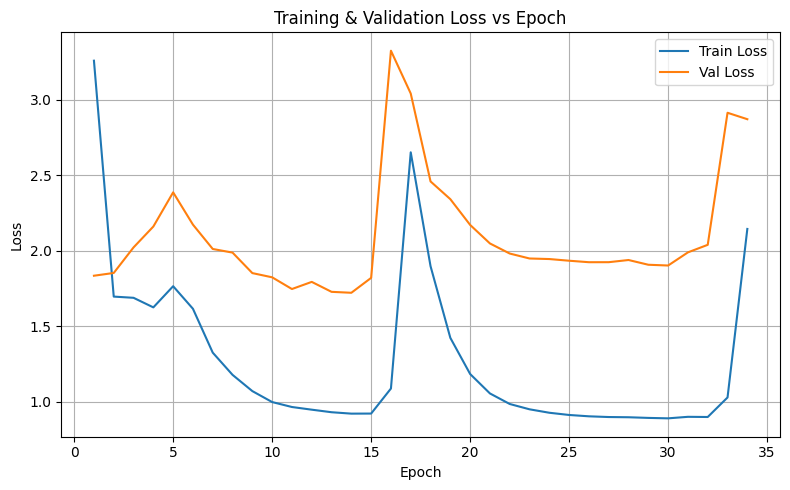

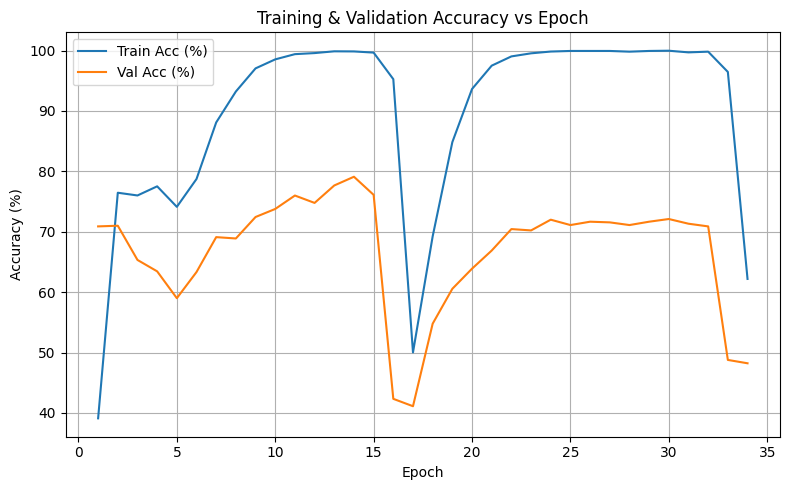

In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# 1) Train log load karo
log_csv = os.path.join(OUTPUT_DIR, "train_log.csv")  # yahi path tumhari notebook mein hai
log_df = pd.read_csv(log_csv)

epochs = log_df["epoch"]

# 2) Loss graph (Train / Val)
plt.figure(figsize=(8, 5))
plt.plot(epochs, log_df["train_loss"], label="Train Loss")
plt.plot(epochs, log_df["val_loss"],   label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss vs Epoch")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=300)   # thesis ke liye image
plt.show()

# 3) Accuracy graph (Train / Val)
plt.figure(figsize=(8, 5))
plt.plot(epochs, log_df["train_acc"] * 100, label="Train Acc (%)")
plt.plot(epochs, log_df["val_acc"]   * 100, label="Val Acc (%)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training & Validation Accuracy vs Epoch")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("accuracy_curve.png", dpi=300)  # thesis ke liye image
plt.show()

# Classifier manual graph

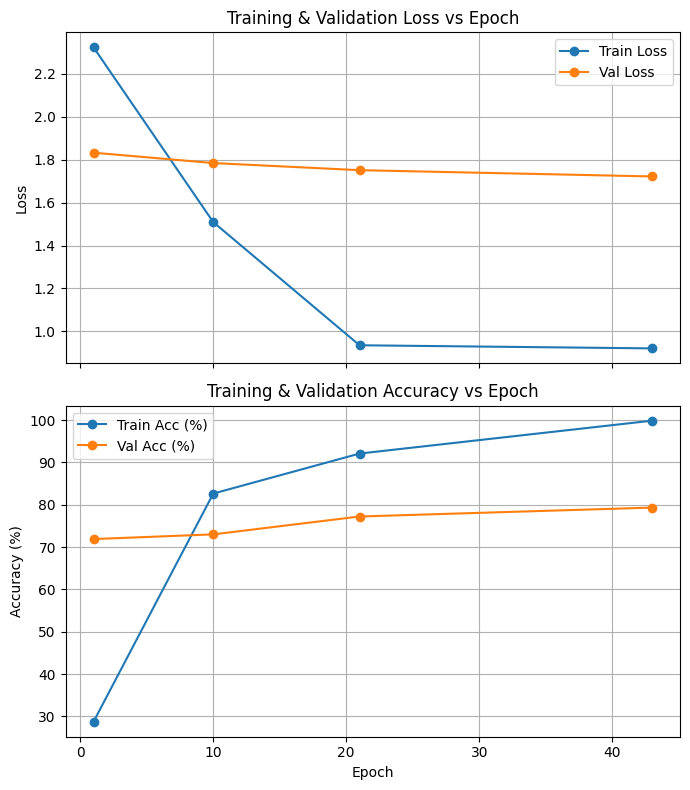

In [7]:
import matplotlib.pyplot as plt

# ---- Table values ----
epochs      = [1, 10, 21, 43]
train_loss  = [2.3234, 1.5093, 0.9355, 0.9210]
val_loss    = [1.8327, 1.7845, 1.7513, 1.7221]

train_acc   = [28.75, 82.64, 92.09, 99.86]   # in %
val_acc     = [71.89, 73.00, 77.22, 79.33]   # in %

# ---- Create figure with 2 subplots ----
fig, axes = plt.subplots(2, 1, figsize=(7, 8), sharex=True)

# 1) Loss graph
axes[0].plot(epochs, train_loss, marker='o', label="Train Loss")
axes[0].plot(epochs, val_loss, marker='o', label="Val Loss")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training & Validation Loss vs Epoch")
axes[0].grid(True)
axes[0].legend()

# 2) Accuracy graph
axes[1].plot(epochs, train_acc, marker='o', label="Train Acc (%)")
axes[1].plot(epochs, val_acc, marker='o', label="Val Acc (%)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Training & Validation Accuracy vs Epoch")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()


# Autoencoder manual graph

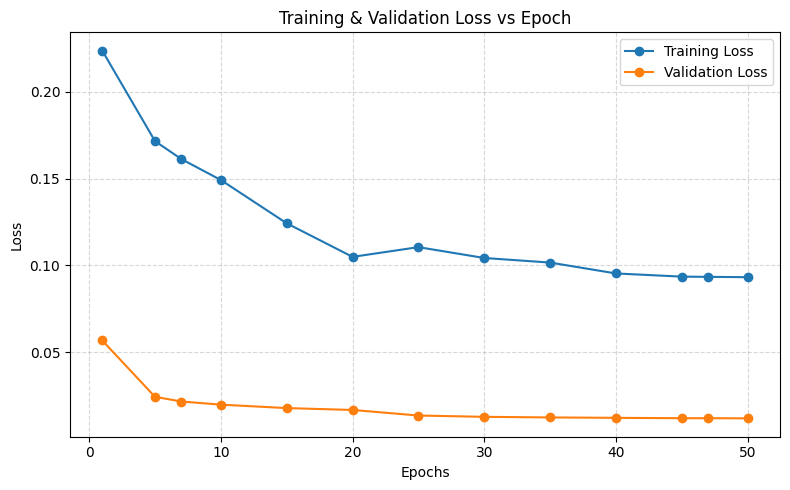

In [8]:
import matplotlib.pyplot as plt

# ---- Table values ----
epochs = [1,5,7,10,15,20,25,30,35,40,45,47,50]
train_loss = [0.22359,0.17157,0.16123,0.14918,0.12427,0.10494,0.11054,0.10429,0.10166,0.09539,0.09357,0.09344,0.09325]
val_loss =   [0.05681,0.02439,0.02170,0.01989,0.01791,0.01683,0.01363,0.01288,0.01253,0.01230,0.01209,0.01209,0.01201]

# ---- Plot ----
plt.figure(figsize=(8,5))
plt.plot(epochs, train_loss, marker='o', label='Training Loss')
plt.plot(epochs, val_loss, marker='o', label='Validation Loss')

plt.title("Training & Validation Loss vs Epoch", fontsize=12)
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# Precision, recall, F1, confusion matrix

In [8]:
# ---- Evaluate on TEST: precision, recall, F1, confusion matrix ----
import torch
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Load best checkpoint
model.load_state_dict(torch.load("/kaggle/working/vit_cls_best.pt", map_location=DEVICE))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for xb, yb in dl_test:
        xb = xb.to(DEVICE)
        logits = model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(yb.numpy())

# Convert to numpy arrays
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# ---- Classification Report ----
print("=== Classification Report (CUB-200) ===")
print(classification_report(all_labels, all_preds, digits=4))

# ---- Confusion Matrix ----
cm = confusion_matrix(all_labels, all_preds)
print("=== Confusion Matrix Shape ===", cm.shape)

=== Classification Report (CUB-200) ===
              precision    recall  f1-score   support

           0     0.6857    0.8000    0.7385        30
           1     0.8000    0.6667    0.7273        30
           2     0.9583    0.8214    0.8846        28
           3     0.7586    0.7333    0.7458        30
           4     0.6471    0.7857    0.7097        14
           5     0.9091    0.9091    0.9091        11
           6     0.9545    0.9130    0.9333        23
           7     0.7778    0.7778    0.7778        18
           8     0.5000    0.4483    0.4727        29
           9     0.9333    0.9333    0.9333        30
          10     0.8095    0.5667    0.6667        30
          11     1.0000    0.9231    0.9600        26
          12     1.0000    0.9000    0.9474        30
          13     0.6905    0.9667    0.8056        30
          14     0.8966    0.9286    0.9123        28
          15     1.0000    0.8929    0.9434        28
          16     1.0000    1.0000    1.00

# Cell 4 — Test Eval + Confusion Matrix (plot & save) + Per-class Stats

TEST Top-1 Accuracy: 78.79%
Saved confusion matrix CSV: /kaggle/working/confusion_matrix.csv


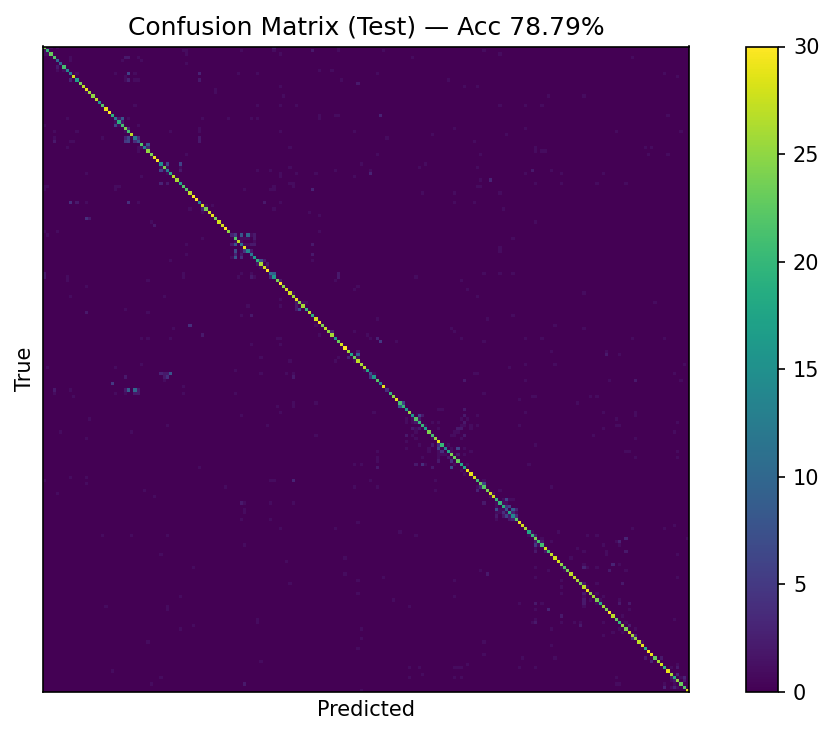

Saved confusion matrix PNG: /kaggle/working/confusion_matrix.png
Saved per-class accuracy CSV: /kaggle/working/per_class_accuracy.csv


,class_id,class_name,total,correct,acc
58,58,059.California Gull,30,3,0.100000
106,106,107.Common Raven,30,4,0.133333
29,29,030.Fish Crow,30,8,0.266667
143,143,144.Common Tern,30,8,0.266667
101,101,102.Western Wood Pewee,30,8,0.266667
70,70,071.Long tailed Jaeger,30,11,0.366667
61,61,062.Herring Gull,30,11,0.366667
28,28,029.American Crow,30,12,0.400000
22,22,023.Brandt Cormorant,29,12,0.413793
48,48,049.Boat tailed Grackle,30,13,0.433333



Top confusions (true -> predicted : count):
059.California Gull -> 064.Ring billed Gull : 10
107.Common Raven -> 029.American Crow : 10
071.Long tailed Jaeger -> 072.Pomarine Jaeger : 9
096.Hooded Oriole -> 098.Scott Oriole : 9
144.Common Tern -> 146.Forsters Tern : 9
023.Brandt Cormorant -> 025.Pelagic Cormorant : 8
031.Black billed Cuckoo -> 033.Yellow billed Cuckoo : 8
062.Herring Gull -> 060.Glaucous winged Gull : 8
066.Western Gull -> 060.Glaucous winged Gull : 8
102.Western Wood Pewee -> 040.Olive sided Flycatcher : 8
112.Great Grey Shrike -> 111.Loggerhead Shrike : 8
064.Ring billed Gull -> 060.Glaucous winged Gull : 7
067.Anna Hummingbird -> 068.Ruby throated Hummingbird : 7
082.Ringed Kingfisher -> 080.Green Kingfisher : 7
131.Vesper Sparrow -> 127.Savannah Sparrow : 7
009.Brewer Blackbird -> 027.Shiny Cowbird : 6
025.Pelagic Cormorant -> 023.Brandt Cormorant : 6
029.American Crow -> 027.Shiny Cowbird : 6
030.Fish Crow -> 027.Shiny Cowbird : 6
037.Acadian Flycatcher -> 039.Le

In [9]:
# Cell 4: Test Eval + Confusion Matrix (plot)
import os, json, numpy as np, pandas as pd, torch, timm
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# --- Load meta & best checkpoint ---
meta_path = os.path.join(OUTPUT_DIR, "meta_cls.json")
best_path = os.path.join(OUTPUT_DIR, "vit_cls_best.pt")

with open(meta_path) as f:
    meta = json.load(f)

num_classes = meta["num_classes"]

model_test = timm.create_model(meta["timm_name"], pretrained=False, num_classes=num_classes)
state = torch.load(best_path, map_location=DEVICE)
model_test.load_state_dict(state, strict=True)
model_test.to(DEVICE)
model_test.eval()

# --- Evaluate on TEST set ---
y_true, y_pred = [], []
with torch.no_grad():
    for xb, yb in dl_test:
        xb = xb.to(DEVICE, non_blocking=True)
        logits = model_test(xb)
        preds = logits.argmax(dim=1).cpu().numpy()
        y_pred.append(preds)
        y_true.append(yb.numpy())

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)

acc = (y_true == y_pred).mean()
print(f"TEST Top-1 Accuracy: {acc*100:.2f}%")

# --- Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred, labels=range(num_classes))

# Save CSV
cm_csv = os.path.join(OUTPUT_DIR, "confusion_matrix.csv")
np.savetxt(cm_csv, cm, fmt="%d", delimiter=",")
print("Saved confusion matrix CSV:", cm_csv)

# Plot & Save PNG (tick labels hidden due to 200 classes)
fig = plt.figure(figsize=(10, 5), dpi=150)
ax = plt.gca()
im = ax.imshow(cm, interpolation="nearest")
ax.set_title(f"Confusion Matrix (Test) — Acc {acc*100:.2f}%")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_xticks([]); ax.set_yticks([])  # 200 labels would clutter; hide them
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
cm_png = os.path.join(OUTPUT_DIR, "confusion_matrix.png")
plt.savefig(cm_png, bbox_inches="tight")
plt.show()
print("Saved confusion matrix PNG:", cm_png)

# --- Per-class accuracy table ---
per_class_total = np.zeros(num_classes, dtype=np.int64)
per_class_correct = np.zeros(num_classes, dtype=np.int64)
for t, p in zip(y_true, y_pred):
    per_class_total[t] += 1
    if t == p:
        per_class_correct[t] += 1
per_class_acc = per_class_correct / np.maximum(1, per_class_total)

id2label = meta.get("id2label", [f"Class_{i}" for i in range(num_classes)])
per_class_df = pd.DataFrame({
    "class_id": np.arange(num_classes),
    "class_name": [id2label[i] if i < len(id2label) else str(i) for i in range(num_classes)],
    "total": per_class_total,
    "correct": per_class_correct,
    "acc": per_class_acc
})
per_class_csv = os.path.join(OUTPUT_DIR, "per_class_accuracy.csv")
per_class_df.to_csv(per_class_csv, index=False)
print("Saved per-class accuracy CSV:", per_class_csv)

display(per_class_df.sort_values("acc").head(10))  # 10 worst classes (quick view)

# --- Top confusions (largest off-diagonal counts) ---
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)
pairs = []
for i in range(num_classes):
    j = int(cm_off[i].argmax())
    cnt = int(cm_off[i, j])
    if cnt > 0:
        pairs.append((cnt, i, j))
pairs = sorted(pairs, key=lambda x: x[0], reverse=True)[:20]

def name(idx):
    return id2label[idx] if idx < len(id2label) else str(idx)

print("\nTop confusions (true -> predicted : count):")
for cnt, i, j in pairs:
    print(f"{name(i)} -> {name(j)} : {cnt}")

# Cell 5 — Phase-1 ZIP (run after Cell 4)

In [10]:
# Cell 5: Make ZIP for Phase-1 artifacts
import os, shutil, glob

OUT = "/kaggle/working"
phase1_dir = os.path.join(OUT, "phase1_out")
os.makedirs(phase1_dir, exist_ok=True)

# expected files
want = [
    "vit_cls_best.pt",
    "meta_cls.json",
    "train_log.csv",
    "confusion_matrix.png",
    "confusion_matrix.csv",
    "per_class_accuracy.csv",
    "labels.txt",
]

# copy if exists
copied = []
for name in want:
    src = os.path.join(OUT, name)
    if os.path.isfile(src):
        shutil.copy2(src, os.path.join(phase1_dir, name))
        copied.append(name)

print("Collected files:", copied)

zip_base = os.path.join(OUT, "ViT_Classifier_CUB200")
shutil.make_archive(zip_base, 'zip', phase1_dir)
print("ZIP created:", zip_base + ".zip")

# quick listing
print("\nContents in phase1_out/:")
for p in sorted(glob.glob(os.path.join(phase1_dir, "*"))):
    print(" -", os.path.basename(p))

Collected files: ['vit_cls_best.pt', 'meta_cls.json', 'train_log.csv', 'confusion_matrix.png', 'confusion_matrix.csv', 'per_class_accuracy.csv', 'labels.txt']
ZIP created: /kaggle/working/ViT_Classifier_CUB200.zip

Contents in phase1_out/:
 - confusion_matrix.csv
 - confusion_matrix.png
 - labels.txt
 - meta_cls.json
 - per_class_accuracy.csv
 - train_log.csv
 - vit_cls_best.pt
